In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [3]:
data = pd.read_csv("sales.csv")

print(data.head())

         date  sales
0  2024-01-01    232
1  2024-01-02    210
2  2024-01-03    286
3  2024-01-04    310
4  2024-01-05    271


In [4]:
data["date"] = pd.to_datetime(data["date"])

In [5]:
data["day"] = data["date"].dt.day
data["month"] = data["date"].dt.month
data["year"] = data["date"].dt.year

In [8]:
X = data[["day","month","year"]]
y = data["sales"]
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [10]:
predictions = model.predict(X_test)

print(predictions)

[267.59617175 268.0874246  270.61149858 269.3974322  274.21401949
 261.63332781 263.10708637 271.59400428 266.94116795 259.10925384
 272.90401188 261.30582591 271.75775523 266.28616414 265.72710158
 256.48923863 259.43675574 269.95649477 265.56335063 258.61800099
 261.79707876 267.7599227  265.46740939 262.61583352]


In [12]:
mse = mean_squared_error(y_test, predictions)

print("Mean Squared Error:", mse)

Mean Squared Error: 2537.4002432516095


In [14]:
import pandas as pd

future = pd.DataFrame({
    "day":[15],
    "month":[4],
    "year":[2025]
})

future_sales = model.predict(future)

print("Predicted Sales:", future_sales)

Predicted Sales: [258.78175194]


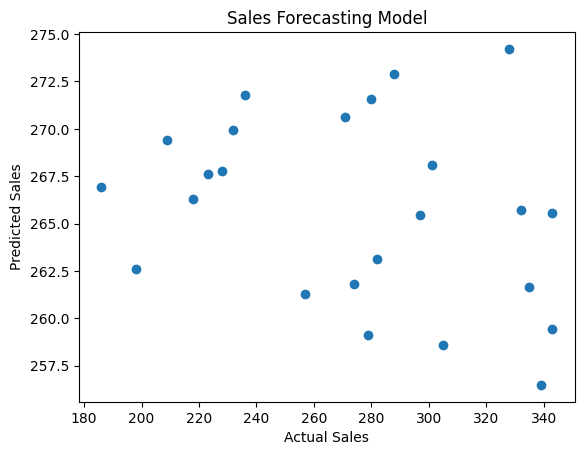

In [15]:
plt.scatter(y_test, predictions)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("Sales Forecasting Model")

plt.show()